In [12]:
import pandas as pd
import numpy as np
import ast
import json
import matplotlib.pyplot as plt

In [13]:
# Load data
df = pd.read_excel('all_data-2026_02_11_161834.xlsx')
kw = pd.read_csv('ubpp_grid_keywords_updated.csv')

print(df.shape, df.columns.tolist())
print(kw.shape, kw.columns.tolist())

(94592, 18) ['source_project_id', 'name', 'funding_amount', 'country_raw', 'start_date', 'recipient_name', 'sector', 'source_data_set', 'funder_name', 'funder_type', 'instrument', 'other_columns', 'goal_raw', 'phase_raw', 'end_date', 'id', 'description', 'country_standardized']
(186, 6) ['keyword', 'concept_family', 'series', 'strategy_level', 'goal', 'additional_description']


# Preprocessing

In [14]:
keep_keys = [
    '2050_ip_outcome', '2050_theme', 'agencies', 'department',
    'desc', 'description', 'description_narrative', 'details_page',
    'focal_areas', 'purpose_name', 'type', 'sector', 'sector_other',
    'short_desc', 'subsector', 'tags', 'theme', 'implementing_agency',
    'partner_agency', 'primary_subject', 'program',
    'project_developent_objective', 'support_strategies'
]

def clean_other_columns(df, col="other_columns", keep_keys=None, new_col="other_columns_cleaned"):
    if keep_keys is None:
        raise ValueError("keep_keys list must be provided")

    def safe_parse(val):
        if pd.isna(val): return {}
        if isinstance(val, dict): return val
        if not isinstance(val, str): return {}
        val_fixed = (
            val.replace("nan", "None")
               .replace("None", "null")
               .replace("True", "true")
               .replace("False", "false")
        )
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, dict): return parsed
        except Exception:
            pass
        try:
            return json.loads(val_fixed.replace("'", '"'))
        except Exception:
            return {}

    def extract_keys(val):
        parsed = safe_parse(val)
        kept = [
            str(parsed.get(k, "")) for k in keep_keys
            if k in parsed and pd.notna(parsed[k]) and parsed[k] != ""
        ]
        return " ".join(kept).strip()

    df[new_col] = df[col].apply(extract_keys)
    return df

df = clean_other_columns(df=df, keep_keys=keep_keys)

df['final_combined_text'] = (
    df['other_columns_cleaned'].astype(str) + ' | '
    + df['name'].astype(str) + ' | '
    + df['sector'].astype(str)
)

print("final_combined_text built. Sample:")
print(df['final_combined_text'].iloc[0][:300])

final_combined_text built. Sample:
Sectors Group Transport policies and institutional development | Water transport (non-urban) | Interisland Shipping Support Project | Transport


In [16]:
# ── Build keyword lookup structures ──────────────────────────────────────────
#
# Matching logic:
#   - Each keyword phrase is matched as a plain substring (lowercased, no regex)
#   - 'additional_description' phrases (split on ; or ,) are also checked
#   - No word-boundary enforcement — simple str.find() style inclusion
#
# To make this fast on 94k rows we pre-build a flat list of
# (keyword_original, [list_of_phrases_to_search_for]) tuples.

def build_match_phrases(kw_df, keyword_col='keyword', desc_col='additional_description'):
    """
    For each keyword row, collect the keyword itself plus any
    additional description phrases as plain lowercase strings.
    Returns: list of dicts with keys: keyword, goal, series, strategy_level, concept_family, phrases
    """
    rows = []
    for _, row in kw_df.iterrows():
        kw = str(row[keyword_col]).strip()
        phrases = [kw.lower()]

        # add additional_description phrases if the column exists
        if desc_col in kw_df.columns and pd.notna(row.get(desc_col)):
            for phrase in str(row[desc_col]).replace(';', ',').split(','):
                phrase = phrase.strip().lower()
                if phrase:
                    phrases.append(phrase)

        rows.append({
            'keyword':         kw,
            'goal':            row.get('goal', ''),
            'series':          row.get('series', ''),
            'strategy_level':  row.get('strategy_level', ''),
            'concept_family':  row.get('concept_family', ''),
            'phrases':         phrases,
        })
    return rows


def match_keywords(text, keyword_rules):
    """
    Pure substring match — no regex.
    Returns list of dicts for every keyword whose phrase appears in text.
    """
    if not isinstance(text, str) or not text.strip():
        return []

    text_lower = text.lower()
    matched = []

    for rule in keyword_rules:
        for phrase in rule['phrases']:
            if phrase in text_lower:          # <-- plain substring, no regex
                matched.append({
                    'keyword':        rule['keyword'],
                    'goal':           rule['goal'],
                    'series':         rule['series'],
                    'strategy_level': rule['strategy_level'],
                    'concept_family': rule['concept_family'],
                })
                break   # don't double-count same keyword via multiple phrases

    return matched


# Build once
keyword_rules = build_match_phrases(kw)
print(f"Keyword rules built: {len(keyword_rules)} keywords")

Keyword rules built: 186 keywords


In [19]:
# ── Apply matching to all project rows ───────────────────────────────────────

THRESHOLD = 1  # ← minimum keyword matches to flag a project; adjust as needed

print(f"Matching {len(df):,} rows against {len(keyword_rules)} keywords...")
raw_matches = df['final_combined_text'].apply(lambda t: match_keywords(t, keyword_rules))

# Core output columns (mirroring v3 pipeline output)
# Some kw columns may have NaN (float) values — coerce to str and drop before sorting

def clean_vals(matches, field):
    seen = set()
    out = []
    for r in matches:
        v = r.get(field)
        if v is None or (isinstance(v, float) and np.isnan(v)):
            continue
        v = str(v).strip()
        if v and v not in seen:
            seen.add(v)
            out.append(v)
    return sorted(out)

df['ubpp_grid_keywords']  = raw_matches.apply(lambda m: clean_vals(m, 'keyword'))
df['ubpp_series']         = raw_matches.apply(lambda m: clean_vals(m, 'series'))
df['ubpp_strategy_level'] = raw_matches.apply(lambda m: clean_vals(m, 'strategy_level'))
df['ubpp_goal']           = raw_matches.apply(lambda m: clean_vals(m, 'goal'))

# Flagging
df['kw_match_count'] = df['ubpp_grid_keywords'].apply(len)
df['kw_flagged']     = df['kw_match_count'] >= THRESHOLD

total   = len(df)
flagged = df['kw_flagged'].sum()
print(f"\nThreshold  : {THRESHOLD} keyword(s)")
print(f"Total rows : {total:,}")
print(f"Flagged    : {flagged:,}  ({flagged/total*100:.1f}%)")
print(f"Not flagged: {total - flagged:,}  ({(total - flagged)/total*100:.1f}%)")

Matching 94,592 rows against 186 keywords...

Threshold  : 1 keyword(s)
Total rows : 94,592
Flagged    : 383  (0.4%)
Not flagged: 94,209  (99.6%)


# Score

In [20]:
# ── Coverage overview ─────────────────────────────────────────────────────────

print("=== Overall coverage ===")
print(f"Total projects         : {total:,}")
print(f"Projects with >=1 label: {flagged:,} ({flagged/total:.1%})")
print(f"Avg keywords / project : {df['kw_match_count'].mean():.2f}")
print(f"Median keywords/project: {df['kw_match_count'].median():.1f}")

print("\n=== Distribution of match counts ===")
print(df['kw_match_count'].value_counts().sort_index().head(15))

=== Overall coverage ===
Total projects         : 94,592
Projects with >=1 label: 383 (0.4%)
Avg keywords / project : 0.01
Median keywords/project: 0.0

=== Distribution of match counts ===
kw_match_count
0    94209
1      236
2       89
3       52
4        3
5        3
Name: count, dtype: int64


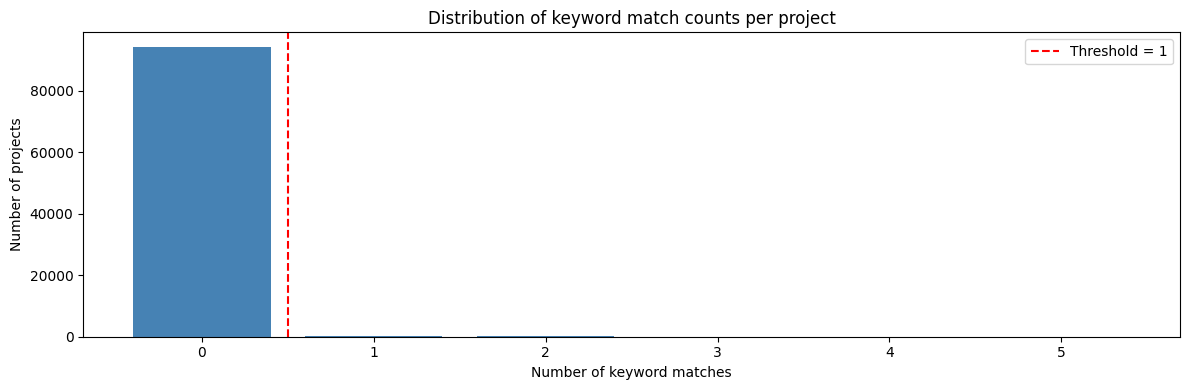

In [21]:
# ── Match count distribution chart ───────────────────────────────────────────

counts = df['kw_match_count'].value_counts().sort_index()
counts_trim = counts[counts.index <= 20]

plt.figure(figsize=(12, 4))
plt.bar(counts_trim.index, counts_trim.values, color='steelblue')
plt.axvline(x=THRESHOLD - 0.5, color='red', linestyle='--', label=f'Threshold = {THRESHOLD}')
plt.xlabel('Number of keyword matches')
plt.ylabel('Number of projects')
plt.title('Distribution of keyword match counts per project')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Most common matched keywords ──────────────────────────────────────────────

from collections import Counter

all_kw = [kw for kws in df['ubpp_grid_keywords'] for kw in kws]
kw_freq = pd.Series(Counter(all_kw)).sort_values(ascending=False)

print("=== Most common matched keywords (top 20) ===")
print(kw_freq.head(20).to_string())

print("\n=== Keywords never matched ===")
matched_set = set(kw_freq.index)
all_keywords = set(kw['keyword'].dropna().unique())
never_matched = sorted(all_keywords - matched_set)
print(f"{len(never_matched)} keywords had zero matches:")
for k in never_matched:
    print(f"  - {k}")

In [ ]:
# ── Inspect flagged projects ──────────────────────────────────────────────────

flagged_df = df[df['kw_flagged']].copy()
flagged_df[['name', 'sector', 'kw_match_count', 'ubpp_grid_keywords', 'ubpp_goal']]\
    .sort_values('kw_match_count', ascending=False)\
    .head(20)